# Customer Churn Prediction

## Problem Statement

Customer churn refers to customers leaving a bank and discontinuing its services. 
Retaining customers is significantly more cost-effective than acquiring new ones. 

In this project, we aim to build machine learning models to predict whether a customer is likely to leave the bank. 
We will use Logistic Regression as a baseline model and Random Forest for improved performance and feature importance analysis.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [3]:
df = pd.read_csv("Churn_Modelling.csv")

df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [4]:
df.shape

(10000, 14)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


In [6]:
df.describe()

,RowNumber,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.00000,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,5000.50000,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,2886.89568,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,1.00000,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,2500.75000,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,5000.50000,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,7500.25000,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,10000.00000,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


### Dataset Summary

- The dataset contains 10,000 customer records.
- The target variable is `Exited` (1 = Customer churned, 0 = Customer stayed).
- No missing values are observed.
- Features include demographic details, account information, and customer activity indicators.


In [7]:
df = df.drop(["RowNumber", "CustomerId", "Surname"], axis=1)

df.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


The columns `RowNumber`, `CustomerId`, and `Surname` were removed because they do not contribute to predicting customer churn and may introduce noise into the model.

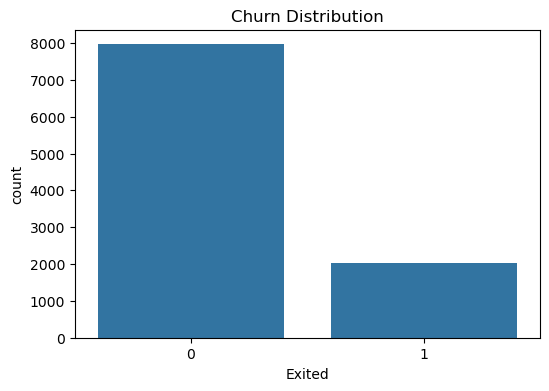

In [8]:
plt.figure(figsize=(6,4))
sns.countplot(x="Exited", data=df)
plt.title("Churn Distribution")
plt.show()

### Churn Distribution Insight

The majority of customers have not churned, while a smaller proportion have exited.
This indicates moderate class imbalance in the dataset.

Although most customers remain with the bank, the churned customers represent potential revenue loss.


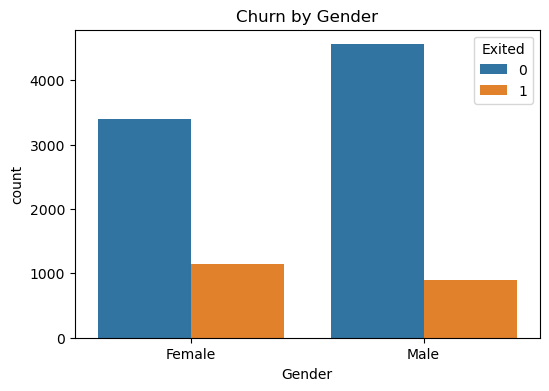

In [9]:
plt.figure(figsize=(6,4))
sns.countplot(x="Gender", hue="Exited", data=df)
plt.title("Churn by Gender")
plt.show()

### Gender-Based Churn Insight

The visualization shows a slight difference in churn rates between male and female customers.

Female customers show a higher churn proportion, this suggests the bank may need targeted retention strategies for that segment.

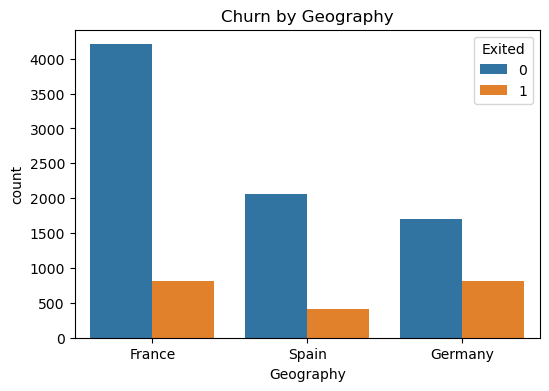

In [10]:
plt.figure(figsize=(6,4))
sns.countplot(x="Geography", hue="Exited", data=df)
plt.title("Churn by Geography")
plt.show()

### Geography-Based Churn Insight

Customers from certain regions, such as Germany, show a higher churn rate compared to others.

This may indicate regional differences in customer satisfaction, competition, or service quality.
The bank should investigate operational factors in high-churn regions.


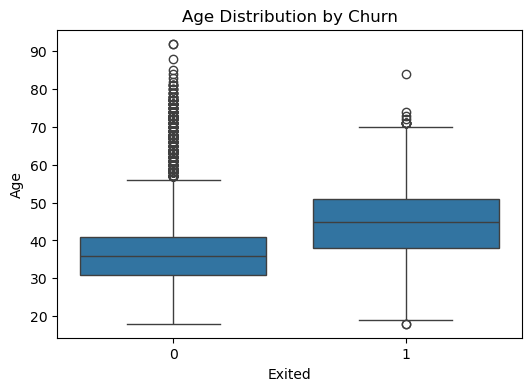

In [11]:
plt.figure(figsize=(6,4))
sns.boxplot(x="Exited", y="Age", data=df)
plt.title("Age Distribution by Churn")
plt.show()

### Age-Based Insight

Customers who churn tend to have a higher median age compared to those who stay.

Older customers may be more sensitive to service quality or competitive offers.
Retention strategies could focus on this demographic group.


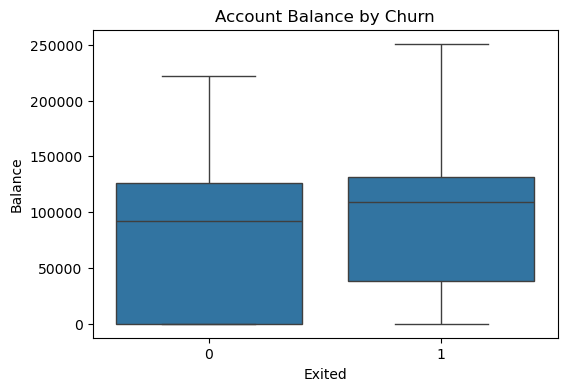

In [12]:
plt.figure(figsize=(6,4))
sns.boxplot(x="Exited", y="Balance", data=df)
plt.title("Account Balance by Churn")
plt.show()

### Balance-Based Insight

Customers with higher account balances appear more likely to churn.

This is concerning because high-balance customers represent higher financial value to the bank.
Targeted retention efforts should prioritize high-value customers.


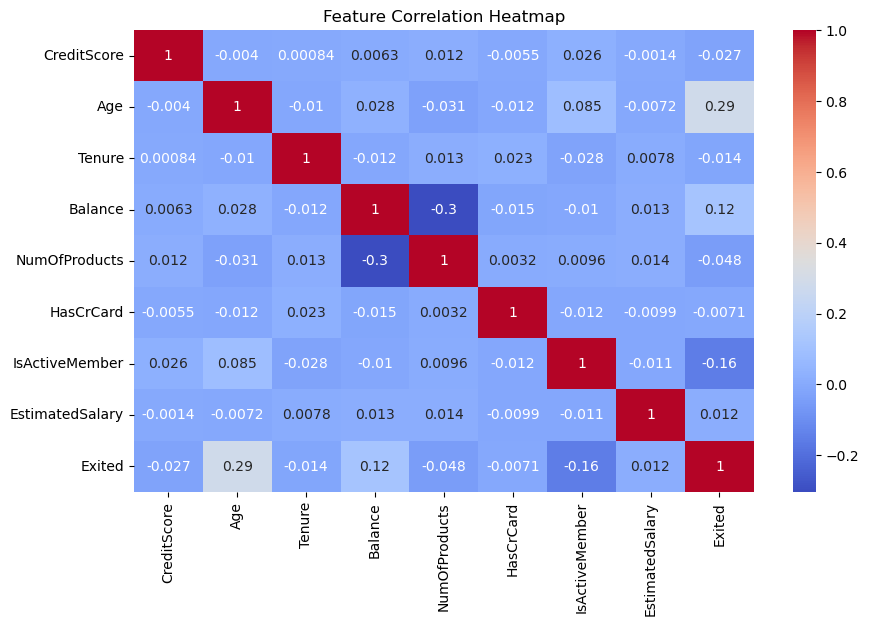

In [14]:
numeric_df = df.select_dtypes(include=np.number)

plt.figure(figsize=(10,6))
sns.heatmap(numeric_df.corr(), annot=True, cmap="coolwarm")
plt.title("Feature Correlation Heatmap")
plt.show()

### Correlation Insight

- Age shows a positive correlation with churn.
- IsActiveMember shows negative correlation with churn.
- Balance also has some positive association with churn.

This suggests that older, inactive customers with higher balances are more likely to leave.


In [15]:
# Encode Gender
le = LabelEncoder()
df["Gender"] = le.fit_transform(df["Gender"])

# One-hot encode Geography
df = pd.get_dummies(df, columns=["Geography"], drop_first=True)

df.head()

,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_Germany,Geography_Spain
0,619,0,42,2,0.00,1,1,1,101348.88,1,False,False
1,608,0,41,1,83807.86,1,0,1,112542.58,0,False,True
2,502,0,42,8,159660.80,3,1,0,113931.57,1,False,False
3,699,0,39,1,0.00,2,0,0,93826.63,0,False,False
4,850,0,43,2,125510.82,1,1,1,79084.10,0,False,True


- Gender was label encoded since it is binary.
- Geography was one-hot encoded to prevent introducing artificial ranking between countries.


In [16]:
X = df.drop("Exited", axis=1)
y = df["Exited"]

In [17]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [18]:
scaler = StandardScaler()

num_cols = X_train.select_dtypes(include=np.number).columns

X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])


In [19]:
log_reg = LogisticRegression(max_iter=1000)
log_reg.fit(X_train, y_train)

y_pred_log = log_reg.predict(X_test)

print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_log))
print(confusion_matrix(y_test, y_pred_log))
print(classification_report(y_test, y_pred_log))

Logistic Regression Accuracy: 0.811
[[1543   64]
 [ 314   79]]
              precision    recall  f1-score   support

           0       0.83      0.96      0.89      1607
           1       0.55      0.20      0.29       393

    accuracy                           0.81      2000
   macro avg       0.69      0.58      0.59      2000
weighted avg       0.78      0.81      0.77      2000



### Key Insights

- Model predicts class 0 (majority class) very well.

- Recall for class 1 is only 20% → model misses most positive cases.

- F1-score for class 1 is very low (0.29).

- Strong class imbalance effect.

Logistic Regression is biased toward majority class.

In [20]:
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print(confusion_matrix(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

Random Forest Accuracy: 0.8665
[[1551   56]
 [ 211  182]]
              precision    recall  f1-score   support

           0       0.88      0.97      0.92      1607
           1       0.76      0.46      0.58       393

    accuracy                           0.87      2000
   macro avg       0.82      0.71      0.75      2000
weighted avg       0.86      0.87      0.85      2000



Random Forest typically performs better because it captures non-linear relationships.

**Major Improvements in Random Forest**
- Accuracy improved (81% → 86.6%)
- Recall for minority class improved:

20% → 46%

- F1-score for class 1 doubled:

0.29 → 0.58

Even though Logistic Regression gives decent accuracy,
it performs poorly for minority class detection.

Random Forest:

Handles non-linear patterns better

Captures feature interactions

Performs significantly better on minority class

Therefore, random Forest is the better model for this dataset.

## Deep Insight 

The dataset is clearly imbalanced:

- Class 0: 1607 samples

- Class 1: 393 samples

Accuracy alone is misleading here.

Macro Average F1:

- Logistic Regression: 0.59

- Random Forest: 0.75

This shows Random Forest generalizes better across both classes.

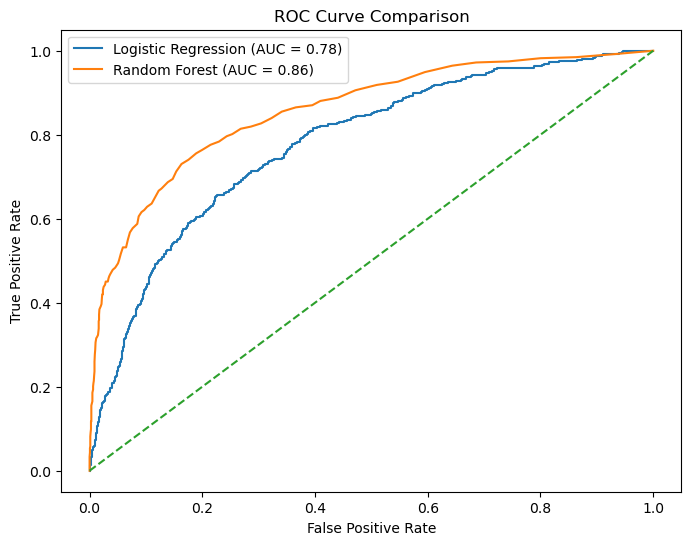

In [22]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# Get predicted probabilities
log_reg_probs = log_reg.predict_proba(X_test)[:, 1]
rf_probs = rf.predict_proba(X_test)[:, 1]

# Compute ROC curves
fpr_lr, tpr_lr, _ = roc_curve(y_test, log_reg_probs)
fpr_rf, tpr_rf, _ = roc_curve(y_test, rf_probs)

# Compute AUC
auc_lr = roc_auc_score(y_test, log_reg_probs)
auc_rf = roc_auc_score(y_test, rf_probs)

# Plot
plt.figure(figsize=(8,6))
plt.plot(fpr_lr, tpr_lr, label=f"Logistic Regression (AUC = {auc_lr:.2f})")
plt.plot(fpr_rf, tpr_rf, label=f"Random Forest (AUC = {auc_rf:.2f})")
plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()

## ROC Curve Comparison

The ROC curve (Receiver Operating Characteristic curve) shows the trade-off 
between True Positive Rate (Recall) and False Positive Rate.

A higher AUC (Area Under Curve) indicates better model performance.

## Insights

- Since Random Forest curve is closer to top-left corner. Higher AUC indicates better class separation ability.

- Logistic Regression likely shows lower AUC due to poor minority recall.

- ROC confirms Random Forest handles imbalance better.

## Feature Importance

Random Forest provides feature importance scores 
based on how much each feature reduces impurity.

Higher importance means stronger influence on prediction.


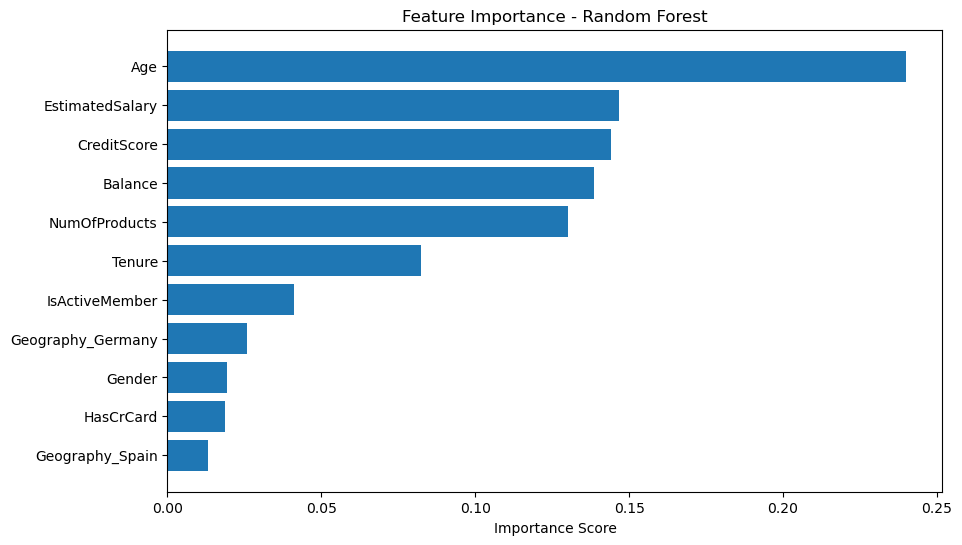

In [23]:
# Get feature importances
importances = rf.feature_importances_
features = X_train.columns

# Create DataFrame
importance_df = pd.DataFrame({
    "Feature": features,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

# Plot
plt.figure(figsize=(10,6))
plt.barh(importance_df["Feature"], importance_df["Importance"])
plt.gca().invert_yaxis()
plt.title("Feature Importance - Random Forest")
plt.xlabel("Importance Score")
plt.show()

## Feature Importance Analysis

Based on the Random Forest feature importance plot, the most influential 
features in predicting customer churn are:

1. Age
2. Estimated Salary
3. Credit Score
4. Balance
5. Number of Products

### Interpretation:

- **Age** is the most important feature, indicating that churn behavior 
  varies significantly across different age groups.

- **Estimated Salary** and **Credit Score** strongly influence churn, 
  suggesting financial stability plays a key role in customer retention.

- **Balance** and **Number of Products** indicate engagement level with the bank.

- Features like **Gender**, **Has Credit Card**, and **Geography_Spain** 
  have relatively low impact on churn prediction.

This suggests that financial behavior and customer lifecycle factors 
are more influential than demographic attributes.



## Model Comparison and Final Selection

Two models were evaluated for customer churn prediction: Logistic Regression and Random Forest.

Logistic Regression achieved an accuracy of **81.1%**, but showed low recall for churned customers (class 1). While it performed well in identifying non-churned customers, it struggled to correctly detect actual churn cases.

Random Forest achieved a higher accuracy of **86.65%** and significantly improved recall and F1-score for churned customers. This indicates better detection of customers who are likely to leave, which is crucial in churn prediction problems.

### Final Model Selection

Random Forest was selected as the final model. Since identifying potential churners is more important than overall accuracy alone, Random Forest provides a more reliable and relevant solution.